In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv('wine_data.csv',header=None ,usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic Acid']

In [6]:
df

,Class label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

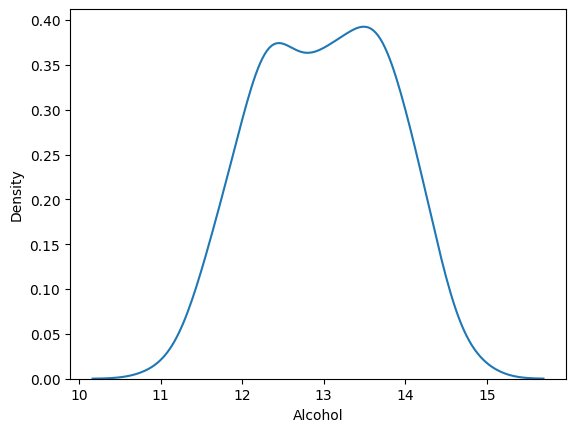

In [7]:
sns.kdeplot(df['Alcohol'])

In [9]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(df.drop('Class label',axis=1),df['Class label'],test_size=0.3,random_state=0)

In [12]:
X_train.shape,X_test.shape

((124, 2), (54, 2))

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() #whenever we talk abt normalization we talk abt minmax.
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled , columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns=X_test.columns)

In [21]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


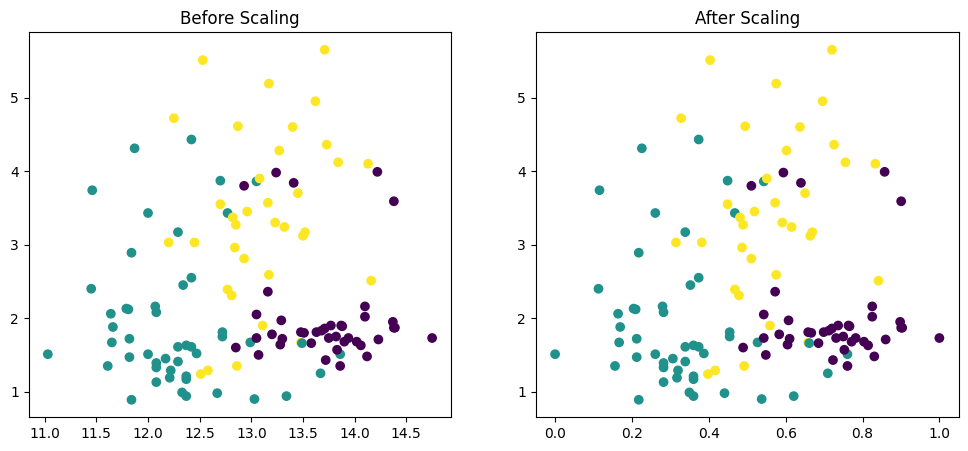

In [29]:
fig , (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(X_train['Alcohol'] , X_train['Malic Acid'] , c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train['Malic Acid'], c=y_train)
ax2.set_title("After Scaling")
plt.show()

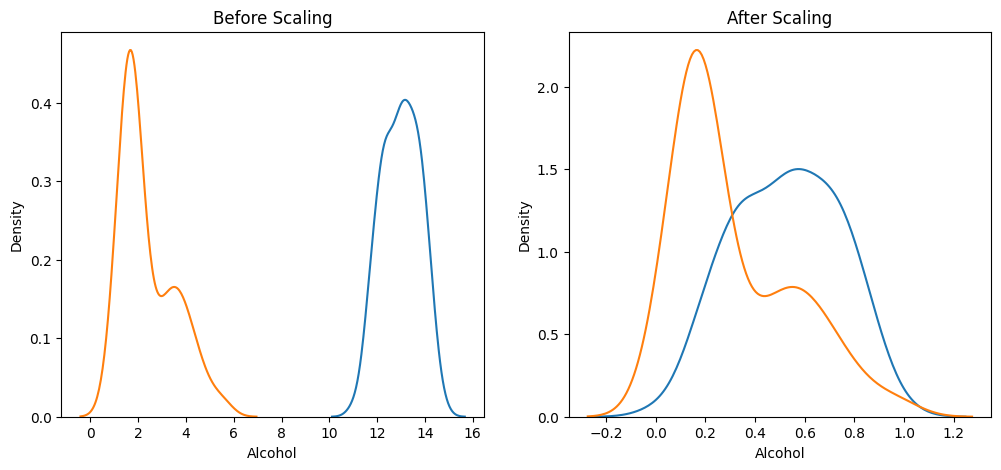

In [33]:
fig , (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

#before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'],ax=ax1)
sns.kdeplot(X_train['Malic Acid'],ax=ax1)

#after scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Alcohol'],ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()

**->Scaling does not change:**

**skewness,**

**outliers,**

**overall distribution shape**

**->Scaling only changes:**

**center (mean),**

**spread (standard deviation)**

Types of Normalization:

1.Mean Normalization: Centers the data, raraely used , instead people use standarization

2.MaxAbsScaling : Used when there is sparsed data , i.e. many 0's. 

3.RobustSCaling : Used if there are many outliers.